# 2. 函数拟合 (PyTorch 版)

## 问题描述：
理论和实验证明，一个两层的ReLU网络可以模拟任何函数[1~5]。请自行定义一个函数, 并使用基于ReLU的神经网络来拟合此函数。

## 要求: 
- 请自行在函数上采样生成训练集和测试集，使用训练集来训练神经网络，使用测试集来验证拟合效果。
- 使用 PyTorch 框架实现。

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子，保证结果可复现
torch.manual_seed(42)
np.random.seed(42)

## 1. 准备数据

请在此处定义你的目标函数 $y = f(x)$，并生成训练集和测试集。

In [11]:
def target_function(x):
    # 定义一个非线性函数 y = sin(x) + 0.5 * x
    return np.sin(x) + 0.5 * x

# 生成数据
# 在 -10 到 10 之间生成 1000 个随机点作为训练集
x_train = np.random.uniform(-10, 10, (1000, 1))
y_train = target_function(x_train)

# 生成测试集，使用均匀分布的点以便绘图平滑
x_test = np.linspace(-10, 10, 200).reshape(-1, 1)
y_test = target_function(x_test)

# 转换为 PyTorch Tensor
x_train_tensor = torch.from_numpy(x_train).float()
y_train_tensor = torch.from_numpy(y_train).float()
x_test_tensor = torch.from_numpy(x_test).float()
y_test_tensor = torch.from_numpy(y_test).float()

print(f"Training data shape: {x_train_tensor.shape}, Testing data shape: {x_test_tensor.shape}")

Training data shape: torch.Size([1000, 1]), Testing data shape: torch.Size([200, 1])


## 2. 建立模型 (Two-layer ReLU Network)

定义一个包含至少一个隐藏层和 ReLU 激活函数的神经网络。

In [12]:
class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
        ####################
        '''定义模型层'''
        # 增加隐藏层神经元数量到 50，以获得更好的拟合能力
        self.layer1 = nn.Linear(1, 50) 
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(50, 1)
        ####################

    def forward(self, x):
        ####################
        '''定义前向传播'''
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        ####################
        return x

model = MyModel()
print(model)

MyModel(
  (layer1): Linear(in_features=1, out_features=50, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=50, out_features=1, bias=True)
)


## 3. 定义损失函数和优化器

In [13]:
# 定义 Loss (通常使用 MSELoss 用于回归任务)
criterion = nn.MSELoss()

# 定义优化器 (如 SGD 或 Adam)
optimizer = optim.Adam(model.parameters(), lr=0.01)

## 4. 训练模型

In [14]:
num_epochs = 1000

for epoch in range(num_epochs):
    # 1. 前向传播
    outputs = model(x_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    
    # 2. 反向传播和优化
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
        pass

Epoch [100/1000], Loss: 0.3935
Epoch [200/1000], Loss: 0.3014
Epoch [300/1000], Loss: 0.2510
Epoch [400/1000], Loss: 0.2187
Epoch [500/1000], Loss: 0.1988
Epoch [600/1000], Loss: 0.1878
Epoch [700/1000], Loss: 0.1815
Epoch [800/1000], Loss: 0.1769
Epoch [900/1000], Loss: 0.1686
Epoch [1000/1000], Loss: 0.1596


## 5. 验证与可视化

使用测试集验证模型，并画出真实曲线与拟合曲线的对比图。

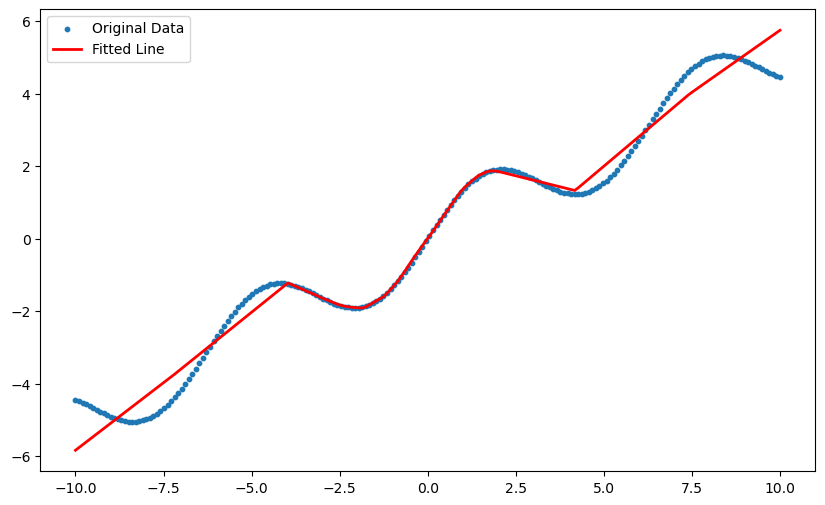

In [15]:
# 切换到评估模式
model.eval()
with torch.no_grad():
    predicted = model(x_test_tensor).numpy()
    pass

# 绘图
plt.figure(figsize=(10, 6))
plt.scatter(x_test, y_test, label='Original Data', s=10)
plt.plot(x_test, predicted, label='Fitted Line', color='red', linewidth=2)
plt.legend()
plt.show()